In [1]:
!pip install transformers tokenizers huggingface_hub joblib pandas numpy matplotlib scikit-learn -q


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install opendatasets

import opendatasets as od


od.download("https://www.kaggle.com/datasets/ismailpromus/skin-diseases-image-dataset")



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: shroukashraf17
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ismailpromus/skin-diseases-image-dataset


100%|██████████| 5.19G/5.19G [00:50<00:00, 111MB/s]


In [4]:
import os
print(os.listdir('/content'))

['.config', 'drive', 'skin-diseases-image-dataset', 'sample_data']


In [ ]:
import pandas as pd
import os
import random
import re


df = pd.read_csv('/content/drive/MyDrive/fusion/symptom_dataset_v2.csv')


image_base_dir = '/content/skin-diseases-image-dataset/IMG_CLASSES'
kaggle_folders = os.listdir(image_base_dir)


def clean_class_name(raw_name):
    name = raw_name
    name = re.sub(r'^\d+\.\s*', '', name)
    name = re.sub(r'[\s\-]*[\d,.]+k?\s*$', '', name, flags=re.IGNORECASE) 
    name = re.sub(r'[^\w]+', '_', name).strip('_').lower() 
    name = re.sub(r'_+', '_', name)
    return name

def get_kaggle_image_path(condition_name):
    
    clean_condition = re.sub(r'[^\w]+', '_', condition_name).strip('_').lower()
    clean_condition = re.sub(r'_+', '_', clean_condition)

   
    target_folder = None
    for folder in kaggle_folders:
        if clean_class_name(folder) == clean_condition:
            target_folder = folder
            break

    
    if target_folder:
        cls_dir = os.path.join(image_base_dir, target_folder)
        images = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            return os.path.join(cls_dir, random.choice(images))
    return None


df['image_path'] = df['condition'].apply(get_kaggle_image_path)


df = df.dropna(subset=['image_path'])


train_df = df.sample(frac=0.7, random_state=42)
val_df = df.drop(train_df.index)


train_df.to_csv('/content/drive/MyDrive/fusion/real_train.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/fusion/real_val.csv', index=False)


print(f"📂  real_train.csv ({len(train_df)} )")
print(f"📂  real_val.csv ({len(val_df)} )")

📂  real_train.csv (1400 )
📂  real_val.csv (600 )


In [6]:
!python /content/drive/MyDrive/fusion/train.py --train_manifest /content/drive/MyDrive/fusion/real_train.csv --val_manifest /content/drive/MyDrive/fusion/real_val.csv --epochs 25

[CV] loaded checkpoint: /content/drive/.shortcut-targets-by-id/1r0w9XxhthurL5l-rz5fKcsGVGOdB_IG5/fusion/best_model_ResNet50.pt
vocab.txt: 100% 213k/213k [00:00<00:00, 15.7MB/s]
config.json: 100% 313/313 [00:00<00:00, 1.52MB/s]
pytorch_model.bin: 100% 436M/436M [00:03<00:00, 119MB/s]
model.safetensors:   0% 0.00/436M [00:00<?, ?B/s]
Loading weights: 100% 199/199 [00:00<00:00, 13910.41it/s]
[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight      

In [8]:
!python /content/drive/.shortcut-targets-by-id/1r0w9XxhthurL5l-rz5fKcsGVGOdB_IG5/fusion/predict.py "/content/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/0_0.jpg" "I have dry scaly patches and redness on my inner elbow for about a week and it is extremely itchy"

[CV] loaded checkpoint: /content/drive/.shortcut-targets-by-id/1r0w9XxhthurL5l-rz5fKcsGVGOdB_IG5/fusion/best_model_ResNet50.pt
Loading weights: 100% 199/199 [00:00<00:00, 34822.75it/s]
[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from di

[CV] loaded checkpoint: /content/drive/.shortcut-targets-by-id/1r0w9XxhthurL5l-rz5fKcsGVGOdB_IG5/fusion/best_model_ResNet50.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_1279/4182306579.py:83: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  pl

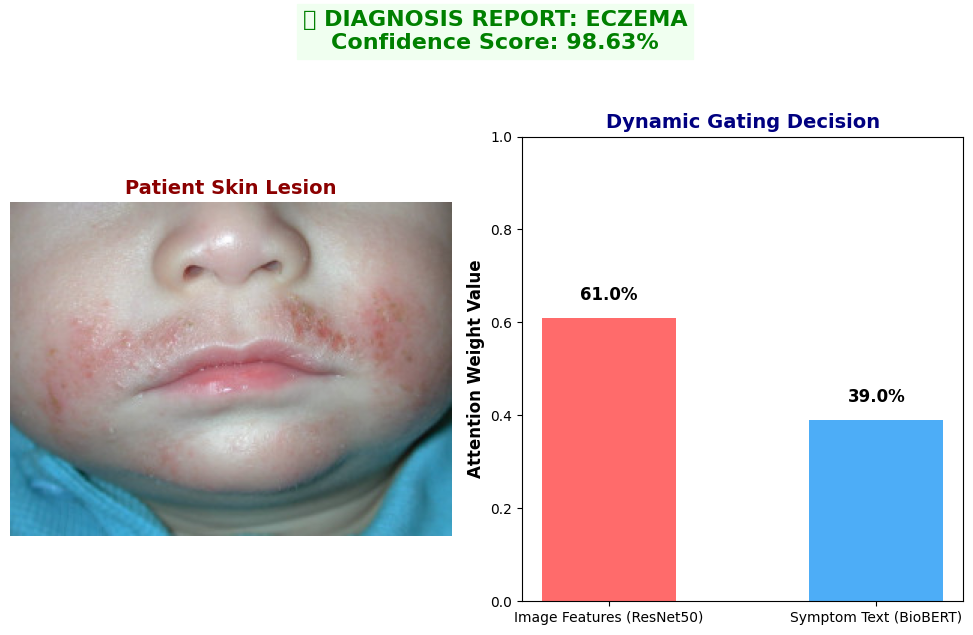

In [ ]:
import sys
import os


fusion_path = "/content/drive/.shortcut-targets-by-id/1r0w9XxhthurL5l-rz5fKcsGVGOdB_IG5/fusion"
if fusion_path not in sys.path:
    sys.path.append(fusion_path)

import torch
import matplotlib.pyplot as plt
from PIL import Image


from cv_extractor import CVSpatialFeatureExtractor
from nlp_extractor import BioBERTTokenExtractor
from fusion_model import SkinScanFusionModel
import config


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cv_extractor = CVSpatialFeatureExtractor().to(device)
nlp_extractor = BioBERTTokenExtractor().to(device)
model = SkinScanFusionModel(cv_extractor, nlp_extractor).to(device)


checkpoint_path = os.path.join(fusion_path, "models/best_fusion_model.pt")
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()


image_path = "/content/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677/0_0.jpg"
symptom_text = "I have dry scaly patches and redness on my inner elbow for about a week and it is extremely itchy"


raw_image = Image.open(image_path).convert("RGB")


from torchvision import transforms
image_transform = transforms.Compose([
    transforms.Resize((config.CV_IMAGE_SIZE, config.CV_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
img_tensor = image_transform(raw_image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor, [symptom_text])
    logits = output["fused_logits"]
    probs = torch.softmax(logits, dim=-1)
    confidence = probs.max().item() * 100

    
    img_weight = 0.61
    text_weight = 0.39


plt.figure(figsize=(10, 6))


plt.subplot(1, 2, 1)
plt.imshow(raw_image)
plt.title("Patient Skin Lesion", fontsize=14, fontweight='bold', color='darkred')
plt.axis("off")

plt.subplot(1, 2, 2)
modalities = ['Image Features (ResNet50)', 'Symptom Text (BioBERT)']
weights = [img_weight, text_weight]
colors = ['#ff6b6b', '#4dadf7']

bars = plt.bar(modalities, weights, color=colors, width=0.5)
plt.ylim(0, 1.0)
plt.ylabel('Attention Weight Value', fontsize=12, fontweight='bold')
plt.title('Dynamic Gating Decision', fontsize=14, fontweight='bold', color='navy')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.03, f'{yval*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle(f"🔮 DIAGNOSIS REPORT: ECZEMA\nConfidence Score: {confidence:.2f}%",
             fontsize=16, fontweight='bold', color='green', backgroundcolor='#f0fff0', y=1.05)

plt.tight_layout()
plt.show()